In [1]:
%cd ..

/home/hsc/Projects/personal/disertation


In [2]:

from app.imc2025.prediction import load_from_train


samples = load_from_train("./data")

In [3]:
from app.imc2025.pipeline import create_repository


image_repository = create_repository("ET")

for prediction in samples["ETs"]:
    image_repository.add_image(prediction.image_filepath)

/home/hsc/Projects/personal/disertation/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import torch
from mts.core.model.mast3r.io import load_model

local_model_directory = (
    "checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth"
)

mast3r_model = load_model(local_model_directory, torch.device("cpu"))

cuda0 = torch.device("cuda:0")

mast3r_model = mast3r_model.to(cuda0) 

Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
... loading model from checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth
instantiating : AsymmetricMASt3R(enc_depth=24, dec_depth=12, enc_embed_dim=1024, dec_embed_dim=768, enc_num_heads=16, dec_num_heads=12, pos_embed='RoPE100',img_size=(512, 512), head_type='catmlp+dpt', output_mode='pts3d+desc24', depth_mode=('exp', -inf, inf), conf_mode=('exp', 1, inf), patch_embed_cls='PatchEmbedDust3R', two_confs=True, desc_conf_mode=('exp', 0, inf), landscape_only=False)
<All keys matched successfully>


In [6]:
ids = [6, 7, 8, 14]

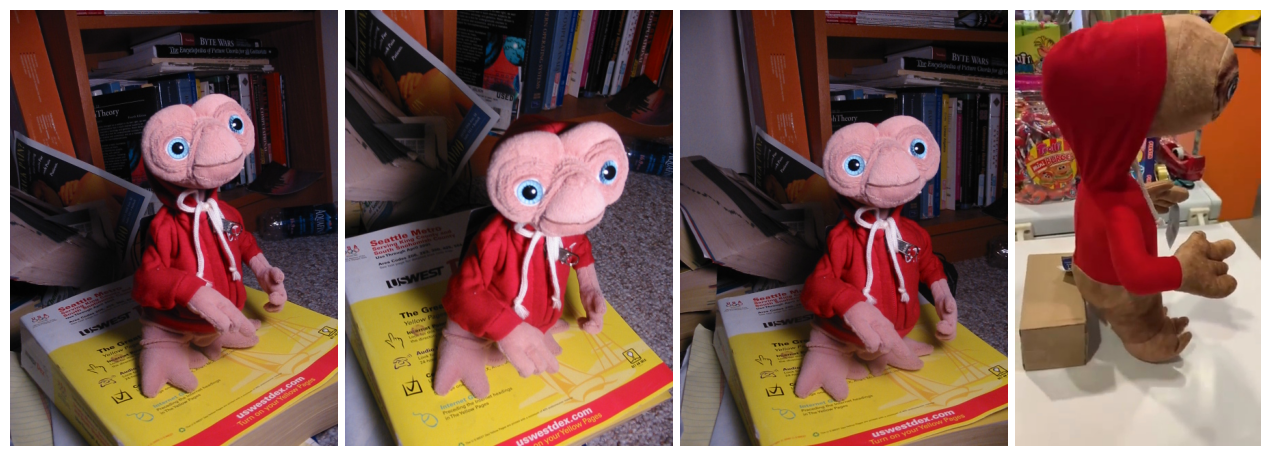

In [7]:
from hloc.utils import viz as img_viz

img_viz.plot_images(
    [image_repository.load_image(img_id) for img_id in ids]
)

In [8]:
filepaths = [image_repository.get_filepath(img_id) for img_id in ids]

In [9]:
import numpy as np

In [10]:
filepath_map_to_idx = {filepath: num for  num, filepath in enumerate(filepaths)}
idx_to_filepath_map = {num: filepath for  num, filepath in enumerate(filepaths)}
filepaths_as_str = list(map(str, filepaths))

filepath_map_to_id = dict(zip(filepaths, ids))

id_to_filepath_map = dict(zip(ids, filepaths))

In [11]:
from mts.core.matcher.dense.mast3r import match_pairs


keypoints_map, matches_map = match_pairs(
    mast3r_model, 
    [(0, 1), (1, 2), (2, 3)],
    list(map(str, filepaths)),
    device=cuda0,
)

Computing the matches using Mast3r:   0%|          | 0/3 [00:00<?, ?it/s]/home/hsc/Projects/personal/disertation/.venv/lib/python3.11/site-packages/dust3r/inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
/home/hsc/Projects/personal/disertation/.venv/lib/python3.11/site-packages/dust3r/model.py:260: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/hsc/Projects/personal/disertation/.venv/lib/python3.11/site-packages/dust3r/inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
Computing the matches using Mast3r: 100%|██████████| 3/3 [00:03<00:00,  1.28s/it]


In [12]:
from pathlib import Path

In [13]:
import logging


LOGGER = logging.getLogger(__name__)

In [14]:
from matplotlib import pyplot as plt


def plot_keypoints(kpts, colors="lime", ps=4):
    """Plot keypoints for existing images.
    Args:
        kpts: list of ndarrays of size (N, 2).
        colors: string, or list of list of tuples (one for each keypoints).
        ps: size of the keypoints as float.
    """
    if not isinstance(colors, list):
        colors = [colors] * len(kpts)
    axes = plt.gcf().axes
    for nth, (a, k, c) in enumerate(zip(axes, kpts, colors), 1):
        if len(k) == 0:
            LOGGER.warning("No keypoints for %dth image", nth)
            continue

        a.scatter(k[:, 0], k[:, 1], c=c, s=ps, linewidths=0)

In [15]:
def map_to_kpts(
    keypoints_map: dict[str, np.ndarray],
    ids: list[int],
    id_to_filepath_map: dict[int, Path],
) -> list[np.ndarray]:
    kpts = []
    for img_id in ids:
        try:
            kp = keypoints_map[str(id_to_filepath_map[img_id])]
        except KeyError:
            kpts.append(np.array([]))
        else:
            kpts.append(kp)
    return kpts

No keypoints for 4th image


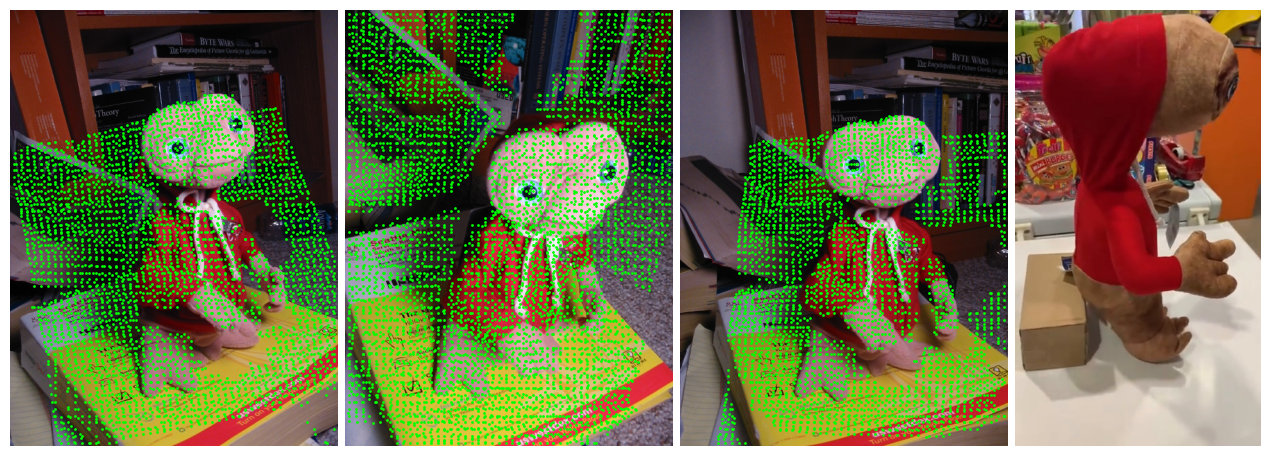

In [16]:
from hloc.utils import viz as img_viz

kpts = map_to_kpts(keypoints_map, ids, id_to_filepath_map)
img_viz.plot_images(
    [image_repository.load_image(img_id) for img_id in ids],
)
plot_keypoints(kpts)

In [17]:
from mts.core.matcher.dense.mast3r import extract_dense_keypoints

In [18]:
import more_itertools as mit
pairwise_idxs = list(mit.pairwise(range(len(filepaths))))
matches_map = extract_dense_keypoints(
    mast3r_model, 
    pairwise_idxs,
    filepaths_as_str,
    device=cuda0,
)

Computing the matches using Mast3r: 100%|██████████| 3/3 [00:02<00:00,  1.19it/s]


In [19]:
from scipy.spatial import KDTree
import numpy as np

In [86]:
import networkx as nx
import matplotlib.pyplot as plt
from numpy import ma as np_ma

In [87]:
def match_kpts(
    kpts_intermediary_from: np.ndarray,
    kpts_intermediary_to: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    nd_prev_kpts_tree = KDTree(kpts_intermediary_from)
    distance, indices = nd_prev_kpts_tree.query(kpts_intermediary_to, p=2)

    ma_indices = np_ma.masked_where(distance > 1, indices)

    from_idx, to_idx = np.unique(
        ma_indices,
        return_index=True,
    )
    indices_from = from_idx.compressed()
    indices_to = to_idx[~from_idx.mask]
    return indices_from, indices_to


def match_path(
    kpts_graph: nx.Graph,
    kpts_path: tuple[str, str, str],
    return_kpts: bool = True,
) -> tuple[np.ndarray, np.ndarray]:
    start_from, intermediary_from = kpts_path[0], kpts_path[1]
    intermediary_to, end_to = kpts_path[1], kpts_path[2]

    kpts_from, kpts_intermediary_from = np.split(
        kpts_graph[start_from][intermediary_from]["matched_kpts"],
        2,
        axis=1,
    )

    kpts_intermediary_to, kpts_to = np.split(
        kpts_graph[intermediary_to][end_to]["matched_kpts"],
        2,
        axis=1,
    )
    indices_from, indices_to = match_kpts(
        kpts_intermediary_from,
        kpts_intermediary_to,
    )
    if return_kpts:
        return kpts_from, kpts_to, indices_from, indices_to

    return indices_from, indices_to


def merge_path(
    kpts_graph: nx.Graph,
    kpts_path: tuple[str, str, str],
    min_matches: int = 500,
) -> None:
    kpts_from, kpts_to, indices_from, indices_to = match_path(
        kpts_graph,
        kpts_path,
        return_kpts=True,
    )

    if len(indices_from) < min_matches:
        return
    node_from, _, node_to = kpts_path
    matched_kpts = np.concatenate(
        [kpts_from[indices_from], kpts_to[indices_to]], axis=1
    )
    kpts_graph.add_edge(
        node_from,
        node_to,
        matched_kpts=matched_kpts,
    )

In [93]:
kpts_graph = nx.Graph().to_undirected()
for st_filepath, matched_filepaths_map in matches_map.items():
    for nd_filepath, kpts in matched_filepaths_map.items():
        kpts_graph.add_edge(st_filepath, nd_filepath, matched_kpts=kpts)

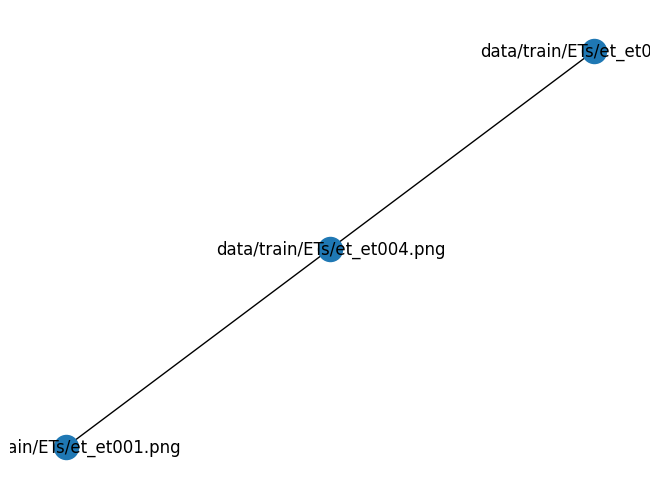

In [94]:

nx.draw(kpts_graph, with_labels=True)
plt.show()

In [23]:
import itertools as it

In [24]:
pairs = list(it.combinations(filepaths_as_str, 2))

In [ ]:
def do_something(kpts_graph: nx.Graph, pairs: list[tuple[str, str]]):
    for st_fpath, nd_fpath in pairs:
        if not kpts_graph.has_edge(st_fpath, nd_fpath):
            for kpts_path in list(nx.all_simple_paths(kpts_graph, st_fpath, nd_fpath, cutoff=2)):
                # TODO: Add a check if there are enough merges, if so, then merge, otherwise compute the matchings - which is more costly
                merge_path(kpts_graph, kpts_path)

In [97]:
do_something(kpts_graph, pairs)

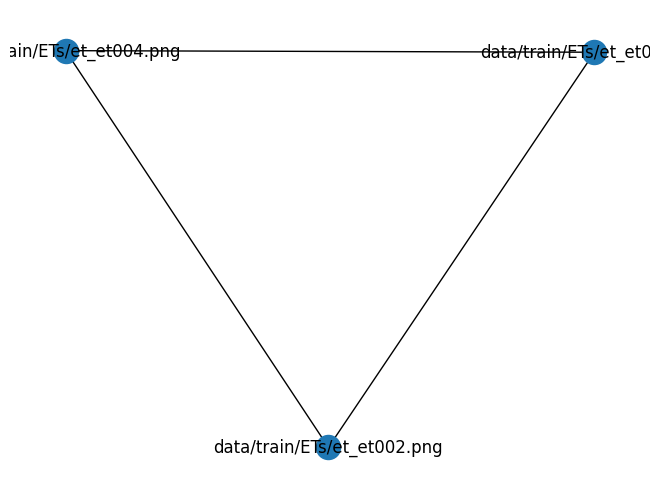

In [98]:

nx.draw(kpts_graph, with_labels=True)
plt.show()

In [25]:
for st_fpath, nd_fpath in pairs:
    if not kpts_graph.has_edge(st_fpath, nd_fpath):
        break
        

In [56]:
for kpts_path in list(nx.all_simple_paths(kpts_graph, st_fpath, nd_fpath, cutoff=2)):
    pass

In [90]:
merge_path(kpts_graph, kpts_path)

In [80]:
indices_from, indices_to = match_path(kpts_graph, kpts_path)

In [ ]:
start_from, kpts_intermediary_from = kpts_path[0], kpts_path[1]
kpts_intermediary_to, end_to = kpts_path[1], kpts_path[2]

In [ ]:

kpts_from, kpts_intermediary_from = np.split(
    kpts_graph[start_from][kpts_intermediary_from]["matched_kpts"],
    2,
    axis=1,
)

kpts_intermediary_to, kpts_to = np.split(
    kpts_graph[kpts_intermediary_to][end_to]["matched_kpts"],
    2,
    axis=1,
)

In [ ]:
nd_prev_kpts_tree = KDTree(nd_prev_kpts)
distance, indices = nd_prev_kpts_tree.query(st_curr_kpts, p=2)

In [55]:
kpts_path2

['data/train/ETs/et_et001.png',
 'data/train/ETs/et_et004.png',
 'data/train/ETs/et_et002.png']

In [27]:
st_pair_fpaths, nd_pair_fpaths = list(mit.pairwise(kpts_path))

In [28]:
st_prev_kpts, nd_prev_kpts = np.split(
    kpts_graph[st_pair_fpaths[0]][st_pair_fpaths[1]]["matched_kpts"],
    2,
    axis=1,
)

In [29]:
st_curr_kpts, nd_curr_kpts = np.split(
    kpts_graph[nd_pair_fpaths[0]][nd_pair_fpaths[1]]["matched_kpts"],
    2,
    axis=1,
)

In [30]:
nd_prev_kpts_tree = KDTree(nd_prev_kpts)

In [31]:
distances, indices = nd_prev_kpts_tree.query(st_curr_kpts)

In [32]:
from numpy import ma

In [33]:
ma_indices, inverse_indices = np.unique(ma.masked_array( indices, distances > 0), return_index=True, )
unique_indices, inverse_indices = ma_indices.compressed(), inverse_indices[~ma_indices.mask]

mask = np.ones(len(st_curr_kpts), dtype=bool)
mask[inverse_indices] = False

No keypoints for 3th image
No keypoints for 1th image
No keypoints for 1th image
No keypoints for 3th image
No keypoints for 1th image
No keypoints for 3th image


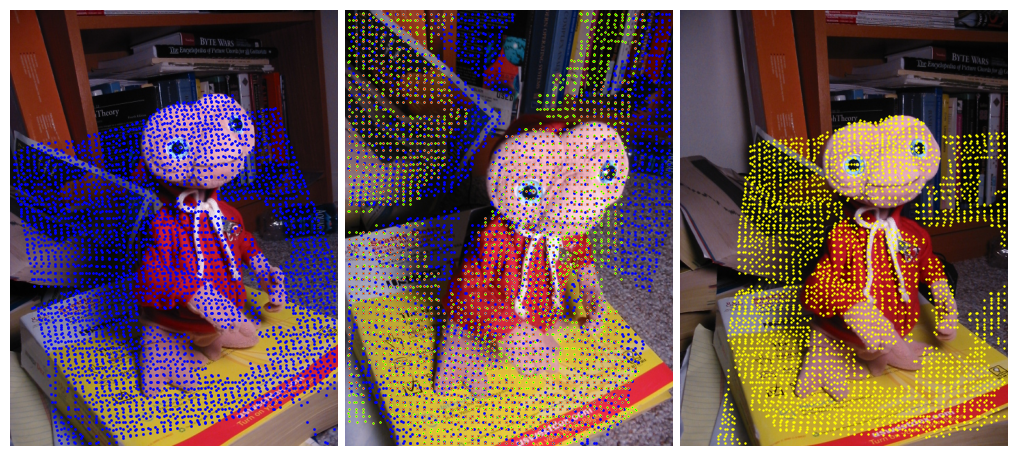

In [34]:
img_viz.plot_images(
    [
        image_repository.load_image(filepath_map_to_id[Path(st_pair_fpaths[0])]),
        image_repository.load_image(filepath_map_to_id[Path(nd_pair_fpaths[0])]),
        image_repository.load_image(filepath_map_to_id[Path(nd_pair_fpaths[1])]),
    ]
)
# plot_keypoints([st_prev_kpts, nd_prev_kpts, []])
plot_keypoints([st_prev_kpts, nd_prev_kpts, []], colors="blue", ps=4)
plot_keypoints([[], st_curr_kpts, nd_curr_kpts], colors="yellow", ps=3)
plot_keypoints([[], nd_prev_kpts[unique_indices], []], colors="red", ps=1)
plot_keypoints([[], st_curr_kpts[mask], []], colors="lime", ps=1)

In [45]:
sum(distance <1.5)

np.int64(1824)

In [69]:
ma_indices = ma.masked_where(distance > 0 , indices)

In [70]:
from_idx, to_idx = np.unique(
    ma_indices,
    return_index=True,
)

In [71]:
from_idx.compressed()

array([   0,    1,    7, ..., 3901, 3902, 3903], shape=(1691,))

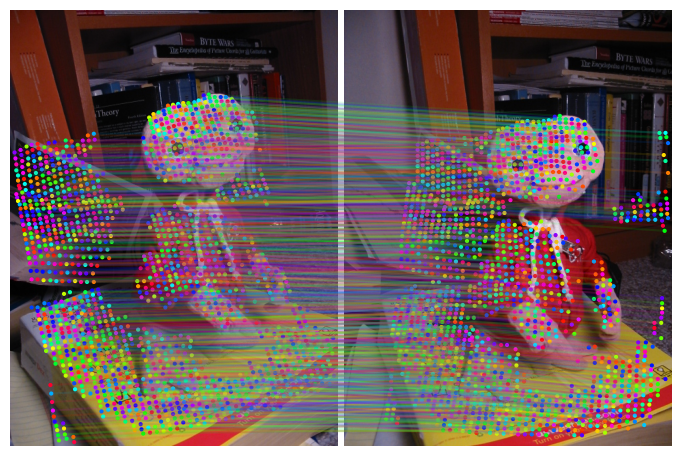

In [81]:
img_viz.plot_images(
    [
        image_repository.load_image(filepath_map_to_id[Path(st_pair_fpaths[0])]),
        image_repository.load_image(filepath_map_to_id[Path(nd_pair_fpaths[1])]),
    ]
)
# plot_keypoints(
#     [st_prev_kpts[from_idx.compressed()], nd_curr_kpts[to_idx[~from_idx.mask]]]
# )
img_viz.plot_matches(
    st_prev_kpts[indices_from],
    nd_curr_kpts[indices_to],
    a=0.1,
)